# MA934 - Assignment 4
Author: Jabir Hussain (2007942)

### Task 1: Diagonally implicit Runge-Kutta (DIRK) methods

For this task, we consider the ODE system $$y'(t) = f(t,y), \qquad y(t) \in \mathbb{R}^r.$$ A general $m$-stage Runge-Kutta (RK) method is described by a Butcher tableau comprised of two vectors $\alpha \in \mathbb{R}^m, \gamma \in \mathbb{R}^m$ and lower triangular matrix $\beta \in \mathbb{R}^{m,m}.$

More specifically, the implicit $m$-stage RK method is defined by the update equation $$y_{n+1} = y_n + h\phi(t_n, y_n; h) \text{ with } \phi(t, y; h) := \sum_{i=1}^m \gamma_i k_i(t, y; h)$$ with $$k_j(t, y; h) = f\left ( t + \alpha_j h, y+h \sum_{l=1}^m \beta_{j, l} k_l(t, y; h) \right).$$ As $\beta$ is lower triangular, $k_j$ is dependent only on its current state and the previous computations $\left \{k_l \right \}_{l<j}.$ This means that instead if solving an $m\cdot r$  coupled nonlinear system, we solve $m$ nonlinear systems of size $r$. The backward Euler tableau can be written as $$y_{n+1} = y_n + hk \qquad k = f(y_n + hk)$$

For a DIRK method, $\beta$ is lower triangular, so the stages can be computed sequentially. Suppose stages $\{k_\ell\}_{\ell<j}$ have already been computed. Define
$$
t_j := t+\alpha_j h,
\qquad
s_j := y + h\sum_{\ell<j}\beta_{j\ell}k_\ell .
$$
Then the stage equation for $k_j$ becomes
$$
k_j = f\bigl(t_j, s_j + h\beta_{jj}k_j\bigr).
$$
We rewrite this as a root-finding problem $F_j(k)=0$, where
$$
F_j(k) := k - f\bigl(t_j, s_j + h\beta_{jj}k\bigr).
$$
If $\beta_{jj}\neq 0$, we solve $F_j(k)=0$ using Newton’s method. Given an initial guess $k^{(0)}$, Newton iterates
$$
k^{(m+1)} = k^{(m)} - \bigl(J_j(k^{(m)})\bigr)^{-1}F_j\bigl(k^{(m)}\bigr),
$$
where the Jacobian matrix is
$$
J_j(k)=DF_j(k)
= I - h\beta_{jj},Df\bigl(t_j, s_j + h\beta_{jj}k\bigr),
$$
and $Df(t,y)$ denotes the Jacobian of $f$ with respect to $y$. Each Newton update therefore requires solving a linear system of size $r$.

If $\beta_{jj}=0$ (an explicit stage), the stage reduces to
$$
k_j = f(t_j,s_j),
$$
so no nonlinear solve is required.

A practical stopping criterion is to terminate Newton once $(|F_j(k^{(m)})|\le \texttt{tol})$ (or once the update $|k^{(m+1)}-k^{(m)}|$ is sufficiently small), with a fixed maximum number of iterations to prevent infinite loops. After all $m$ stages are computed, the DIRK update is
$$
y_{n+1}=y + h\sum_{i=1}^m \gamma_i k_i.
$$

---


### Section 1.2.1: Convergence rates from Runge–Kutta order conditions

In this part, we determine the global convergence order of the given two-stage DIRK family by checking Runge–Kutta order conditions in the $(\alpha,\beta,\gamma)$ notation.

If the local truncation error is $O(h^{p+1})$, then the global error at a fixed final time is $O(h^p)$. In order to identify the global order $p$, we aim to find the highest $p$ for which the corresponding order conditions hold.

Let $m$ be the number of stages. For an $m$-stage RK method with coefficients $(\alpha,\beta,\gamma)$ such that
$$
\alpha_i=\sum_{j=1}^m \beta_{ij}\qquad (i=1,\dots,m),
$$

We use the following orders, that:

- **Order 1**
  $$\sum_{i=1}^m \gamma_i = 1.$$

- **Order 2**
  $$\sum_{i=1}^m \gamma_i \alpha_i = \frac12.$$

- **Order 3**
  $$\sum_{i=1}^m \gamma_i \alpha_i^2 = \frac13,\qquad
    \sum_{i=1}^m\sum_{j=1}^m \gamma_i\,\beta_{ij}\,\alpha_j = \frac16.$$

The assignment brief specifies the two-stage tableau
$$
\begin{array}{c|cc}
x & x & 0\\
1-x & 1-2x & x\\
\hline
& \tfrac12 & \tfrac12
\end{array}
$$
so with $m=2$ we have
$$
\alpha=\begin{pmatrix}x\\ 1-x\end{pmatrix},\qquad
\gamma=\begin{pmatrix}\tfrac12\\ \tfrac12\end{pmatrix},\qquad
\beta=\begin{pmatrix}x&0\\ 1-2x&x\end{pmatrix}.
$$

First, we check the relation $\alpha_i=\sum_j\beta_{ij}$:
$$
\beta_{11}+\beta_{12}=x=\alpha_1
$$
$$
\beta_{21}+\beta_{22}=(1-2x)+x=1-x=\alpha_2.
$$
Thus, the order conditions apply.

**Order 1:**  
$$\gamma_1+\gamma_2=\tfrac12+\tfrac12=1,$$
so the method is at least first order for any $x$.

**Order 2:**  
$$\sum_{i=1}^2 \gamma_i\alpha_i=\tfrac12 x+\tfrac12(1-x)=\tfrac12,$$
so the method is at least second order for any $x$.

**Order 3:**  
First third-order condition:
$$
\sum_{i=1}^2 \gamma_i\alpha_i^2
=\tfrac12\big(x^2+(1-x)^2\big)
=\tfrac12-x+x^2.
$$
Imposing $\tfrac12-x+x^2=\tfrac13$ yields
$$
x^2-x+\tfrac16=0
\quad\Longrightarrow\quad
x=\tfrac12\pm \tfrac{\sqrt3}{6}.
$$

Now, by the second third-order condition:
$$
\sum_{i,j}\gamma_i\beta_{ij}\alpha_j
=\tfrac12(x\cdot x)+\tfrac12\big((1-2x)\cdot x + x(1-x)\big)
= x-x^2.
$$
Imposing $x-x^2=\tfrac16$ gives the same quadratic $x^2-x+\tfrac16=0$. Thus, the method satisfies the third-order conditions iff
$$
x=\tfrac12\pm \tfrac{\sqrt3}{6}.
$$

The assignment requires $x\in\{0,\tfrac14,\tfrac12+\tfrac{\sqrt3}{6}\}$. Therefore:

- For $x=0$ and $x=\tfrac14$, the method satisfies the order 1 and 2 conditions but not the order 3 conditions, so it has global order $p=2$ (and thus one-step error $O(h^3)$).
- For $x=\tfrac12+\tfrac{\sqrt3}{6}$, the order 3 conditions also hold, so it has global order $p=3$ (and thus one-step error $O(h^4)$).

These predicted convergence rates will be verified numerically in Task 1.2.2 using experimental orders of convergence.

---


### Section 1.2.2: EOCs for the test ODE

In Task 1.2.2 we verify the convergence rates predicted in Task 1.2.1 using experimental orders of convergence (EOC).
We solve the initial value problem
$$y'(t)=f(t,y)$$ $$f(t,y_1,y_2)=\begin{pmatrix}y_2\ y_2(1-2y_1)\end{pmatrix}$$ $$t\in[0,10],\quad y(0)=(2,-2)^T.$$
An exact solution is available in the provided template notebook, so we can measure an error directly.
For a time grid $t_n = nh$ with $h=10/N$, we define the max-in-time error $$e(h) = \max_{0\le n\le N} |y_n - y_{\text{exact}}(t_n)|_2.$$
Under step halving $h \mapsto h/2$, the EOC is estimated by
$$\mathrm{EOC}(h)\approx \frac{\log(e(h)/e(h/2))}{\log 2}.$$
We run this for the Pareschi–Russo DIRK family at $x\in \{0, 1/4, 1/2 + \sqrt{3}/6 \}$ and check that the observed EOCs match the predicted global orders.

In [69]:
# required imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import solve, norm

We wrap the test problem in the provided vector class, tracking T, RHS evaluations via `fcount`, whilst providing `exact`, `u0`, `f`, and `Df`. This keeps the convergence study code generic.

In [70]:
class VectorProblem:
    def __init__(self):
        self.T = 10.0
        self.fcount = 0

    def reset_count(self):
        self.fcount = 0

    def exact(self, t):
        """
        Exact solution from the provided template notebook.
        Returns shape (2, len(t)) if t is array-like, else shape (2,).
        """
        t = np.asarray(t, dtype=float)
        e = np.exp(t)
        den = 2.0 * e - 1.0
        y1 = 2.0 * e / den
        y2 = -2.0 * e / (den * den)  # equals -2 e^t / (4 e^{2t} - 4 e^t + 1)
        Y = np.vstack([y1, y2])
        return Y[:, 0] if Y.shape[1] == 1 else Y

    def u0(self):
        y0 = self.exact([0.0])
        assert y0.shape == (2,)
        return y0

    def f(self, t, y):
        self.fcount += 1
        return np.array([y[1], y[1] * (1.0 - 2.0 * y[0])], dtype=float)

    def Df(self, t, y):
        return np.array([[0.0, 1.0],
                         [-2.0 * y[1], 1.0 - 2.0 * y[0]]], dtype=float)

We use a standard Newton method for vector-valued root finding, as in the template, we stop when $|F(x)|\le \texttt{tol}$. Otherwise, we solve a linear system for the Newton update. Assertions are used so that convergence occurs within the iteration budget. The `evolve` driver repeatedly calls a `stepper(tau, t_n, y_n)` and returns arrays $t_n$ and $y_n$.

In [71]:
def newton(F, DF, x0, n_iter=50, tol=1e-10):
    x = x0.copy()
    converged = False

    for i in range(n_iter):
        Fx = F(x)
        if Fx.dot(Fx) <= tol**2:
            converged = True
            break
        J = DF(x)
        assert J.shape[0] == J.shape[1] == len(x)
        delta = solve(J, Fx)
        x -= delta

    assert converged, "Newton's method doesn't converge within the iteration limit."
    return x


def evolve(stepper, tau, N, y0):
    t = np.zeros(N + 1, dtype=float)
    y = np.zeros((len(y0), N + 1), dtype=float)
    y[:, 0] = y0

    for n in range(N):
        t[n + 1] = t[n] + tau
        y[:, n + 1] = stepper(tau, t[n], y[:, n])

    assert np.isclose(t[-1], N * tau)
    return t, y

A DIRK method is defined by $(\alpha,\beta,\gamma)$. For stage $j$, the lower-triangular structure of $\beta$ means only $k_j$ is implicit once earlier stages are known, so we solve a dimension-$r$ nonlinear system per stage.
We implement:
* `pareschi_russo_tableau(x)` returning $(\alpha,\beta,\gamma)$
* `dirk_step(...)` computing one DIRK step using Newton per implicit stage
* `make_dirk_stepper(problem, tableau)` building a `stepper(tau,t,y)` closure for `evolve`
We include assertions to catch inconsistent tableau inputs and to ensure we are actually using a lower-triangular DIRK matrix.

In [72]:
def pareschi_russo_tableau(x):
    alpha = np.array([x, 1.0 - x], dtype=float)
    beta = np.array([[x, 0.0],
                     [1.0 - 2.0 * x, x]], dtype=float)
    gamma = np.array([0.5, 0.5], dtype=float)

    # Assertions: correct shapes and DIRK structure
    assert alpha.shape == (2,)
    assert beta.shape == (2, 2)
    assert gamma.shape == (2,)
    assert np.allclose(beta, np.tril(beta)), "beta must be lower triangular for DIRK."

    return alpha, beta, gamma


def dirk_step(tau, t, y, f, Df, alpha, beta, gamma, newton_tol=1e-10, newton_iter=50):
    m = len(alpha)
    r = len(y)

    k = np.zeros((m, r), dtype=float)

    for j in range(m):
        tj = t + alpha[j] * tau

        # s_j = y + tau * sum_{l<j} beta_{j,l} k_l
        sj = y.copy()
        if j > 0:
            sj = sj + tau * (beta[j, :j] @ k[:j, :])

        bjj = beta[j, j]

        # explicit stage if beta_jj = 0
        if np.isclose(bjj, 0.0):
            k[j, :] = f(tj, sj)
            continue

        # Solve stage equation k = f(tj, sj + tau*beta_jj*k)
        F = lambda kk: kk - f(tj, sj + tau * bjj * kk)
        DF = lambda kk: np.eye(r) - tau * bjj * Df(tj, sj + tau * bjj * kk)

        # initial guess: explicit slope at (tj, sj)
        k0 = f(tj, sj)
        k[j, :] = newton(F, DF, k0, n_iter=newton_iter, tol=newton_tol)

    return y + tau * (gamma @ k)


def make_dirk_stepper(problem, tableau, newton_tol=1e-10, newton_iter=50):
    alpha, beta, gamma = tableau
    return lambda tau, t, y: dirk_step(
        tau, t, y,
        f=problem.f,
        Df=problem.Df,
        alpha=alpha,
        beta=beta,
        gamma=gamma,
        newton_tol=newton_tol,
        newton_iter=newton_iter
    )

We now define:
* `max_error(problem, t, y)` computing $e(h)=\max_n(|y_n-y_{\text{exact}}(t_n)|_2)$
* `compute_eoc(errors)` computing EOC under halving $h$ by the formulae provided at the beginning of this subsection
* `run_study(...)` produces a results table for a given tableau. We refine geometrically $N=N_0 2^k$.

In [73]:
def max_error(problem, t, y):
    Yex = problem.exact(t)                 # shape (2, N+1)
    diff = y - Yex
    return np.max(norm(diff, axis=0))


def compute_eoc(errors):
    errors = np.asarray(errors, dtype=float)
    return np.log(errors[:-1] / errors[1:]) / np.log(2.0)


def run_study(problem, tableau, Ns, newton_tol=1e-10, newton_iter=50):
    T = problem.T
    errors = []
    fcounts = []

    for N in Ns:
        N = int(N)
        assert N > 0
        tau = T / N

        problem.reset_count()
        stepper = make_dirk_stepper(problem, tableau, newton_tol=newton_tol, newton_iter=newton_iter)
        t, y = evolve(stepper, tau=tau, N=N, y0=problem.u0())

        errors.append(max_error(problem, t, y))
        fcounts.append(problem.fcount)

    errors = np.asarray(errors, dtype=float)
    eoc = np.full_like(errors, np.nan)
    eoc[1:] = compute_eoc(errors)

    df = pd.DataFrame({
        "N": Ns.astype(int),
        "h": problem.T / Ns,
        "error": errors,
        "EOC": eoc,
        "fcount": np.asarray(fcounts, dtype=int),
    })

    return df

We run the study for the three prescribed (x) values. We expect:
* $x=0$ and $x=1/4$: EOC $\approx 2$
* $x=1/2+\sqrt{3}/6$: EOC $\approx 3$
We report a table for each method and one log–log plot of error vs $h$.


 x = 0


,N,h,error,EOC,fcount
0,50,0.200000,0.057244,NaN,100
1,100,0.100000,0.012530,2.191742,200
2,200,0.050000,0.002894,2.114076,400
3,400,0.025000,0.000689,2.070694,800
4,800,0.012500,0.000168,2.035939,1600
5,1600,0.006250,0.000041,2.017942,3200
6,3200,0.003125,0.000010,2.009056,6400



 x = 1/4


,N,h,error,EOC,fcount
0,50,0.200000,0.005231,NaN,353
1,100,0.100000,0.001295,2.013767,677
2,200,0.050000,0.000328,1.981914,1305
3,400,0.025000,0.000082,2.000763,2529
4,800,0.012500,0.000020,2.000191,4939
5,1600,0.006250,0.000005,1.999959,9715
6,3200,0.003125,0.000001,1.999979,19210



 x = 1/2 + sqrt(3)/6


,N,h,error,EOC,fcount
0,50,0.200000,8.023322e-03,NaN,388
1,100,0.100000,1.206824e-03,2.732984,731
2,200,0.050000,1.694120e-04,2.832608,1389
3,400,0.025000,2.265019e-05,2.902941,2673
4,800,0.012500,2.928069e-06,2.951502,5159
5,1600,0.006250,3.724442e-07,2.974853,10023
6,3200,0.003125,4.696281e-08,2.987434,19629


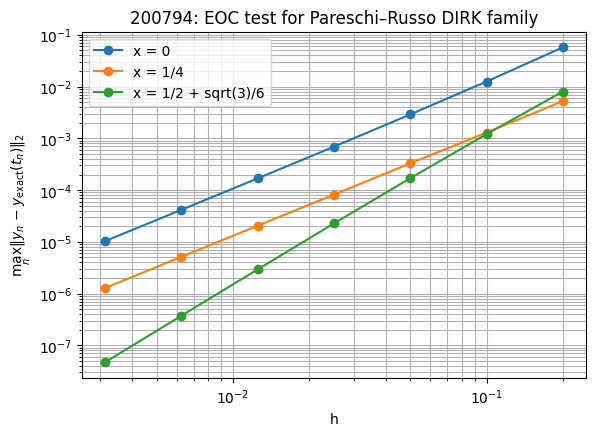

In [74]:
prob = VectorProblem()
assert np.allclose(prob.u0(), prob.exact([0.0]))
assert prob.exact([0.0]).shape == (2,)

# Refinement grid: N = N0 * 2^k
N0 = 50
K = 6
Ns = N0 * (2 ** np.arange(K + 1))
assert np.all(Ns[1:] == 2 * Ns[:-1])

# Three prescribed methods
x_map = {
    "x = 0": 0.0,
    "x = 1/4": 0.25,
    "x = 1/2 + sqrt(3)/6": 0.5 + np.sqrt(3.0) / 6.0,
}

results = {}
for name, x in x_map.items():
    tab = pareschi_russo_tableau(x)
    results[name] = run_study(prob, tab, Ns, newton_tol=1e-10, newton_iter=50)

# Display tables (purposeful output)
for name in results:
    print("\n", name)
    display(results[name])

# Plot error vs h (markers shown)
plt.figure(figsize=(6.5, 4.5))
for name, df in results.items():
    plt.loglog(df["h"], df["error"], marker="o", linewidth=1.5, label=name)

plt.xlabel("h")
plt.ylabel(r"$\max_n \|y_n - y_{\mathrm{exact}}(t_n)\|_2$")
plt.title("200794: EOC test for Pareschi–Russo DIRK family")
plt.grid(True, which="both")
plt.legend()
plt.show()

When $x=0$ and $x=\frac{1}{4}$, the EOC values tends to 2, matching the order-condition predicted value of 2. For the third order case $x=\frac{1}{2} + \frac{\sqrt{3}}{6}$, the EOC values approach 3. Both instances match the global order derived in section 1.2.1.

---

## Task 2 - Heat equation
### Section 1.3.1: Discretisation Summary

This segment of the assignment solves a vector-valued heat equation for functions $u_k (k=1, ..., q)$ satisfying $$\partial_t u_k(t,x) = \mu \partial_{xx}u_k(t,x), \qquad \text{ in } (0, T) \times (0, 1)$$ where $\mu$ is a fixed constant. The Dirichlet boundary conditions $$u(t,0) = u_L \in \mathbb{R}^q, \qquad u(t,1) = u_R \in \mathbb{R}^q$$ for $t \in [0, T]$ and initial conditions $$u(0,x) = u_0(x) \in \mathbb{R}^q$$ for $x \in [0,1]$. In the code provided in `template4`, $\mu = \frac{1}{50}$ and $T=1$. The Dirichlet boundary conditions are constant: $$u(t,0) = u_L = 1, \qquad u(t,1) = u_R = 1.$$ The initial condition is matched by a known exact solution $u(0,x) = u_{\text{exact}}(0,x).$ The exact solution is given by 1 plus decaying sinusoidal eigenmodes of the Laplacian, in the form $$\text{mode}_v(t,x) = e^{-(v\pi)^2\mu t}\sin(v\pi x).$$

The sine modes vanish at $x=0$ and $x=1$, satisfying the Dirichlet conditions. In component form, it shows that
$$
u_k(t,x) = \begin{cases}
u_1(t,x) = 1 + \text{mode}_2(t,x) & \text{for } k = 1,\\
u_2(t,x) = 1 + \text{mode}_3(t,x) + \text{mode}_4(t,x) & \text{for } k = 2 \text{ if } q > 1 \\
u_k(t,x) = 1 & \text{if } k \geq 3.
\end{cases}
$$

The code discretises by creating a uniform grid with `points` number of nodes via `np.linspace(0,1,points)`. $h = \frac{1}{\text{points} - 1}$ with $P$ interior points (where $P = \text{points} - 2$.) The vector `u` holds the interior spatial solution values with length $N = qP$.


With $N=qP$, the `diffusion` method builds a matrix $A \in \mathbb{R^{N\times N}}$, which represents the second-difference approximation of the second order derivative on the interior gridpoints. More specifically, for interior indices $i=1,...,P$ and components $k=1, ..., q,$ we get the Laplacian $$ \partial_{xx}u_k(t, x_i) \approx \frac{ u_{k, i-1}(t) - 2u_{k,i}(t) + u_{k, i+1}(t) }{ h^2 } $$

From this, we get a linear method-of-lines ODE system for the interior values in the form $$\frac{d}{dt} u_{k, i}(t) = \frac{\mu}{h^2}\left( u_{k, i-1}(t) - 2u_{k,i}(t) + u_{k, i+1}(t) \right)$$
where the boundary conditions $u_{k,0}(t) = u_{L,k}, u_{k, P+1}(t) = u_{R,k}$ (`self.uL[k-1]` and `self.uR[k-1]`) are substituted in. This can be written in the vectorised form $$u'(t) = Au(t) + b$$ where $A$ is the matrix generated in `diffusion()` and $b$ are the imposed Dirichlet boundary values. The Jacobian is the same as matrix $A$ through linearity and constant coefficients.

---

### Section 1.3.2.

We will now use the two implicit RK methods to investigate convergence rates. Firstly, we write the `Heat` class (directly from `template4`):


In [75]:
class Heat:
    def __init__(self,q,points):
        self.points = points-2 # without two end points
        self.x = np.linspace(0,1,points)[1:-1]
        # parameters
        self.mu = 1/50
        self.h = 1/(points-1)
        self.q = q              # system of q uncoupled heat equations
        self.T = 1              # final time
        self.uL = np.array(q*[1.]) # left side boundary conditions
        self.uR = np.array(q*[1.]) # right side boundary conditions
        h = 1/points            # step size for space
        self.fcount = 0

    def N0(self,explicit=True):
        # this is the expected limit for stability of the FE method
        return ( 2 * int(self.T * self.mu / self.h**2 ) if explicit else 5 )

    def exact(self,t):
        mode = lambda v: np.exp(-(v*np.pi)**2*self.mu*t)*\
                         np.sin(v*np.pi*self.x)
        ret = np.array(self.q*self.points*[1.])
        # add something to the first component
        ret[::self.q] += mode(2)
        # also add something to the second component (if it exists)
        if self.q > 1:
            ret[1::self.q] += mode(3) + mode(4)
        return ret
    # initial conditions
    def u0(self):
        return self.exact(0)

    # matrix for diffusion operator (d_xx)
    def diffusion(self):
        N = self.q * self.points
        ret = np.zeros((N,N))
        for i in range(self.points):
            for j in range(self.q):
                if i>0:
                    ret[self.q*i+j][self.q*(i-1)+j] = self.mu/self.h**2
                ret[self.q*i+j][self.q*i+j] = -2*self.mu/self.h**2
                if i<self.points-1:
                    ret[self.q*i+j][self.q*(i+1)+j] = self.mu/self.h**2
        return ret

    # right hand side for ODE
    def f(self,t,u):
        self.fcount += 1
        ret = self.diffusion() @ u
        # boundary conditions
        for j in range(self.q):
            ret[j]  += self.mu/self.h**2*self.uL[j]
            ret[-self.q+j] += self.mu/self.h**2*self.uR[j]
        return ret
    # and its Jacobian
    def Df(self,t,u):
        ret = self.diffusion()
        return ret

The `points` variable will be large enough such that the truncation error is small. Then, we adjust $\tau$ so that we can view the conergence rate graphically. The error takes the form $$||\text{ error }|| \approx C_1 h^2 + C_2 \tau^r.$$ The expected behaviour is that if $\tau$ is small enough, the temporal error will be significant, and for very small $\tau$ then the spatial error will cause some plateauing. Interestingly, the `f(t,u)` method in the provided `Heat` class rebuilds matrix $A$ at each call. As the problem scales, this becomes computationally expensive. I'll use this as an opportunity to the baseline provided model with the following:

*   If we construct a sparse diffusion matrix and the boundary vector at once, then it removes the need to repeatedly reconstruct the matrices. This offers a more memory-efficient solution.
*   We can take this a step further and apply the second-difference stencil directly through array reshaping. This avoids matrix reconstruction and matrix vector multiplication entirely. I will ensure the final array values are within some tolerance of one another, to ensure the solutions are equivalent.

In [76]:
import scipy.sparse as sp
from scipy.sparse import diags, kron, eye
import scipy.sparse.linalg as spla
from scipy.sparse import diags, identity, csr_matrix
from scipy.linalg import lu_factor, lu_solve, solve_banded

from time import perf_counter

For the sparse operator approach, since the equation is linear in the form $$u'(t) = Au(t) + b,$$ we can build the second-difference Laplacian $L$ directly with stencil (1,-2,1) using Scipy's `diags` function, where $$
L=\alpha\begin{bmatrix}
-2 & 1 \\
1 & -2 & 1\\
& \ddots & \ddots & \ddots\\
&& 1 & -2 & 1\\
&&& 1 & -2
\end{bmatrix} \in\mathbb{R}^{P\times P}.$$
By generating the matrix in sparse format, it removes the need for both looping and zero entries allocation. We can use `sp.kron` to use the Kronecker product for the full operator $$A = \frac{\mu}{h^2}(L \otimes I_q)$$

In [77]:
def laplacian_1d(n_interior):
    assert n_interior >= 1
    main = -2.0 * np.ones(n_interior)
    off  =  1.0 * np.ones(n_interior - 1)
    L = diags([off, main, off], offsets=[-1, 0, 1], format="csr")
    return L


def diffusion_operator(mu, h, q, n_interior) -> sp.csr_matrix:
    assert mu > 0 and h > 0
    assert q >= 1 and n_interior >= 1
    L = laplacian_1d(n_interior)
    Iq = eye(q, format="csr")
    A = (mu / h**2) * kron(L, Iq, format="csr")
    return A


def boundary_vector(mu, h, q, n_interior, uL, uR):
    uR = np.asarray(uR, dtype=float)
    assert uL.shape == (q,) and uR.shape == (q,)
    b = np.zeros(q * n_interior, dtype=float)
    scale = mu / h**2
    b[0:q] += scale * uL
    b[-q:] += scale * uR
    return b


The centred second-difference is local, as it only requires its neighbouring values and itself to be calculated. With this, we can reshape `u` into a 2D array of shape $(P,q)$ and apply the stencil: $$(Au)_{k,i} = \alpha(u_{k, i-1} - 2u_{k,i} + u_{k, i+1}).$$ We can insert the Dirichlet boundaries directly into the ends of the array.

In [78]:
def diffusion_stencil(u, mu, h, q, n_interior, uL, uR):
    u = np.asarray(u, dtype=float)
    uL = np.asarray(uL, dtype=float)
    uR = np.asarray(uR, dtype=float)
    assert u.shape == (q * n_interior,)
    assert uL.shape == (q,) and uR.shape == (q,)

    U = u.reshape(n_interior, q)  # (space, component)
    out = np.empty_like(U)

    scale = mu / h**2

    if n_interior == 1:
        # Single interior point: second difference uses both boundaries
        out[0] = scale * (uL - 2.0 * U[0] + uR)
    else:
        out[1:-1] = scale * (U[:-2] - 2.0 * U[1:-1] + U[2:])
        out[0]    = scale * (uL     - 2.0 * U[0]    + U[1])
        out[-1]   = scale * (U[-2]  - 2.0 * U[-1]   + uR)

    return out.reshape(q * n_interior)


Rather than rewriting the base class, I created a subclass. This subclass implements the same ODE however it allows the user to specify which method is used: the baseline method, the dense cached matrix, the sparse cached matrix and the direct stencil approach.
* Baseline: for every `f(t,u)` call, it constructs the dense diffusion matrix. Because it's reconstructed per call, this is computationally inefficient.
* Dense Cached: this precomputes the dense matrix, removing the need to reconstruct the matrix each time. This still uses dense products for each evaluation nonetheless.
* Spare Cached: this precomputes the sparse matrix once; since the matrix is tri-diagonal, we can store it in CSR format which is more memory efficient.
* Stencil: this applies the 3-point stencil directly onto a reshaped state, with time complexity $O(N)$.

In [79]:
# checks if Heat class exists
# if not (i.e. cell is run in isolation), error is raised
try:
    Heat
except NameError as e:
    raise NameError("Heat class is not defined.") from e

class HeatExtended(Heat):
    def __init__(self, q, points, method="dense_cached"):
        super().__init__(q, points)
        self.method = method

        self._A_dense, self._A_sparse = None, None
        self._b = None

        if method == "dense_cached":
            self._A_dense = super().diffusion()

        if method in {"sparse_cached", "stencil"}:
            self._A_sparse = diffusion_operator(self.mu, self.h, self.q, self.points)
            self._b = boundary_vector(self.mu, self.h, self.q, self.points, self.uL, self.uR)

    def reset_count(self):
      self.fcount = 0

    def dense_diffusion(self):
        if self._A_dense is None:
            self._A_dense = super().diffusion()
        return self._A_dense

    def f(self, t, u):
      if self.method == "baseline":
          # baseline already increments fcount inside Heat.f
          return super().f(t, u)

      # for all non-baseline backends, we must increment here
      self.fcount += 1

      if self.method == "dense_cached":
          A = self.dense_diffusion()
          ret = A @ u
          c = self.mu / self.h**2
          for j in range(self.q):
              ret[j] += c * self.uL[j]
              ret[-self.q + j] += c * self.uR[j]
          return ret

      if self.method == "sparse_cached":
          return self._A_sparse @ u + self._b

      if self.method == "stencil":
          return diffusion_stencil(u, self.mu, self.h, self.q, self.points, self.uL, self.uR)

      raise ValueError(f"Unknown method={self.method!r}")


    def Df(self, t, u):
        if self.method == "baseline":
            return super().Df(t, u)

        if self.method == "dense_cached":
            return self.dense_diffusion()

        if self.method in {"sparse_cached", "stencil"}:
            return self._A_sparse

        raise ValueError(f"Unknown method={self.method!r}")

The implementation in Task 1 is a general solver using Newton per implicit iteration. In this case, we can exploit the stage equations linearity and solve it directly via $$(I-\tau \beta_{jj}A)k_j = f(t_j, s_j) \text{ for } f(t_j, s_j) = As_j + b.$$ Not only is this more computationally-efficient, it avoids incompatibility between numpy's solve method with sparse Jacobians. We'll use a cached LU factorisation for the sparse method.

In [80]:
def make_dirk_stepper_linear_heat(problem: HeatExtended, tableau):
    """
    DIRK stepper for linear heat MOL problems using direct stage solves.
    Requires problem backend:
      - dense_cached (dense A)
      - sparse_cached (sparse A, uses sparse LU)
      - stencil (matrix-free; uses banded solves)
    """
    alpha, beta, gamma = tableau
    alpha = np.asarray(alpha, dtype=float)
    beta  = np.asarray(beta, dtype=float)
    gamma = np.asarray(gamma, dtype=float)
    m = len(alpha)

    assert beta.shape == (m, m)
    assert gamma.shape == (m,)
    assert np.allclose(beta, np.tril(beta)), "DIRK requires lower-triangular beta."

    # Cache solvers for each diagonal coefficient per tau
    solver_cache = {}

    # For sparse_cached: LU factorisation cache of (I - cA)
    def solve_shifted_sparse(c, rhs):
        key = float(c)
        if key not in solver_cache:
            A = problem._A_sparse.tocsc()
            M = (sp.eye(A.shape[0], format="csc") - c * A)
            solver_cache[key] = spla.splu(M).solve
        return solver_cache[key](rhs)

    # For stencil: banded solve per component (multiple RHS columns at once)
    def solve_shifted_banded(c, rhs):
        q = problem.q
        P = problem.points
        sigma = c * problem.mu / problem.h**2  # since A already has mu/h^2 scaling
        # (I - c*A) corresponds to (I - c*(mu/h^2)*L) => diag 1+2*sigma, off -sigma
        diag = (1.0 + 2.0 * sigma) * np.ones(P)
        off  = (-sigma) * np.ones(P - 1)

        ab = np.zeros((3, P))
        ab[0, 1:]  = off
        ab[1, :]   = diag
        ab[2, :-1] = off

        R = rhs.reshape(P, q)
        X = solve_banded((1, 1), ab, R)
        return X.reshape(P * q)

    def solve_shifted_dense(c, rhs):
        A = problem.dense_diffusion()
        M = np.eye(A.shape[0]) - c * A
        return np.linalg.solve(M, rhs)

    def stepper(tau, t, y):
        r = y.size
        k = np.zeros((m, r), dtype=float)

        for j in range(m):
            tj = t + alpha[j] * tau

            sj = y.copy()
            if j > 0:
                sj += tau * (beta[j, :j] @ k[:j, :])

            bjj = beta[j, j]
            rhs = problem.f(tj, sj)

            if np.isclose(bjj, 0.0):
                k[j, :] = rhs
            else:
                c = tau * bjj
                if problem.method == "sparse_cached":
                    k[j, :] = solve_shifted_sparse(c, rhs)
                elif problem.method == "stencil":
                    k[j, :] = solve_shifted_banded(c, rhs)
                elif problem.method == "dense_cached":
                    k[j, :] = solve_shifted_dense(c, rhs)
                else:
                    # baseline not recommended here (it rebuilds A repeatedly)
                    k[j, :] = solve_shifted_dense(c, rhs)

        return y + tau * (gamma @ k)

    return stepper


The functions below give insight into the effectiveness of each implementation. The max error is given by $$\text{error}(\tau) = \max ||U^n - U_{\text{exact}}(t_n)|| \text{ for } 0 \leq n \leq N$$ where $\tau = T/N$.

The `compute_eoc` function calculates the experimental order of convergence by the formula $$\text{EOC} = \frac{E_i / E_{i+1}}{\log 2}$$

In [81]:
def max_error(problem, t, y):
    return float(np.max([norm(y[:, n] - problem.exact(t[n])) for n in range(len(t))]))

def compute_eoc(errors):
    e = np.asarray(errors, dtype=float)
    out = np.full_like(e, np.nan)
    out[1:] = np.log(e[:-1] / e[1:]) / np.log(2.0)
    return out


def run_study(problem: HeatExtended, tableau, Ns):
    T = problem.T
    rows = []
    for N in map(int, Ns):
        tau = T / N
        problem.reset_count()

        stepper = make_dirk_stepper_linear_heat(problem, tableau)

        t0 = perf_counter()
        t, y = evolve(stepper, tau=tau, N=N, y0=problem.u0())
        runtime = perf_counter() - t0

        rows.append({
            "N": N,
            "tau": tau,
            "error": max_error(problem, t, y),
            "runtime_s": runtime,
            "fcount": int(problem.fcount),
        })

    df = pd.DataFrame(rows)
    df["EOC"] = compute_eoc(df["error"].values)
    return df


def plot_error_vs_tau(results, title):
    plt.figure()
    for (method, backend), grp in results.groupby(["method", "backend"]):
        grp = grp.sort_values("tau")
        plt.loglog(grp["tau"], grp["error"], marker="o", label=f"{method} | {backend}")
    plt.xlabel(r"$\tau$")
    plt.ylabel(r"$\max_n \|y_n - y_{\mathrm{exact}}(t_n)\|_2$")
    plt.title(title)
    plt.grid(True, which="both")
    plt.legend()
    plt.show()


To check the validity of the different methods I've implemented, I tried implementing directly but it increased the runtime significantly (by 40+ minutes). As a proxy, I decided to implement it a random vector test with each method which returns assertions should the methods not work properly.

In [82]:
def rhs_sanity_check():
    rng = np.random.default_rng(2007942)

    for (q_test, points_test) in [(2, 3), (2, 50)]:  # corner + typical
        prob_base  = HeatExtended(q_test, points_test, method="baseline")
        prob_dense = HeatExtended(q_test, points_test, method="dense_cached")
        prob_sprs  = HeatExtended(q_test, points_test, method="sparse_cached")
        prob_sten  = HeatExtended(q_test, points_test, method="stencil")

        for _ in range(3):  # a few random vectors
            u = rng.standard_normal(prob_base.u0().shape)

            f_base  = prob_base.f(0.0, u)
            f_dense = prob_dense.f(0.0, u)
            f_sprs  = prob_sprs.f(0.0, u)
            f_sten  = prob_sten.f(0.0, u)

            if not np.allclose(f_dense, f_base, rtol=1e-10, atol=1e-12):
                raise AssertionError(f"RHS mismatch: dense_cached vs baseline (points={points_test})")
            if not np.allclose(f_sprs, f_base, rtol=1e-10, atol=1e-12):
                raise AssertionError(f"RHS mismatch: sparse_cached vs baseline (points={points_test})")
            if not np.allclose(f_sten, f_base, rtol=1e-10, atol=1e-12):
                raise AssertionError(f"RHS mismatch: stencil vs baseline (points={points_test})")

    return "RHS sanity checks passed."

rhs_sanity_check()


'RHS sanity checks passed.'

For the testing, we set $q=2, P=600$. For each DIRK tableau from Task 1, we run the experiment for $N \in {5, 10, 20, 40, 80, 160, 320}$ and use all four methods implemented. The output is organised in a Pandas DataFrame comparing the maximum error, runtime in seconds and the experimental order of convergence. Please note, given it is a comparison of several methods, the cell took around 10 minutes to execute on my home computer.

In [83]:
x1 = 1/4
x2 = 1/2 + np.sqrt(3)/6
tab1 = pareschi_russo_tableau(x1)
tab2 = pareschi_russo_tableau(x2)

q = 2
points = 600
Ns = 5 * (2 ** np.arange(0, 7))

def run_all_backends(tab, method_name):
    problems = {
        "baseline":     HeatExtended(q, points, method="baseline"),
        "dense_cached": HeatExtended(q, points, method="dense_cached"),
        "sparse_cached":HeatExtended(q, points, method="sparse_cached"),
        "stencil":      HeatExtended(q, points, method="stencil"),
    }
    out = []
    for backend, prob in problems.items():
        # baseline is included for completeness but may be very slow at large points
        df = run_study(prob, tab, Ns)
        df.insert(0, "backend", backend)
        df.insert(0, "methods", method_name)
        out.append(df)
    return pd.concat(out, ignore_index=True)

results1 = run_all_backends(tab1, "DIRK(x1)")
results2 = run_all_backends(tab2, "DIRK(x2)")
results = pd.concat([results1, results2], ignore_index=True)

results


,methods,backend,N,tau,error,runtime_s,fcount,EOC
0,DIRK(x1),baseline,5,0.200000,0.054062,1.138901,10,NaN
1,DIRK(x1),baseline,10,0.100000,0.013469,2.238713,20,2.004989
2,DIRK(x1),baseline,20,0.050000,0.003172,4.631811,40,2.086217
3,DIRK(x1),baseline,40,0.025000,0.000604,9.740977,80,2.392093
4,DIRK(x1),baseline,80,0.012500,0.000078,22.090741,160,2.953089
5,DIRK(x1),baseline,160,0.006250,0.000211,38.927425,320,-1.437213
6,DIRK(x1),baseline,320,0.003125,0.000250,77.016469,640,-0.243533
7,DIRK(x1),dense_cached,5,0.200000,0.054062,1.147633,10,NaN
8,DIRK(x1),dense_cached,10,0.100000,0.013469,2.116410,20,2.004989
9,DIRK(x1),dense_cached,20,0.050000,0.003172,4.250950,40,2.086217


The results highlight the following:
* The error values are generally the same across all implementations
* The EOC column shows that when $N>20$, the EOC varies from $\sim$ -1.5 to $\sim$ 4 across all the implementations for both `DIRK(x1)` and `DIRK(x2)`.
* Baseline and the Dense Cached implementations are significantly slower, with the stencil based approach offering a ~$10^3$ speed up.

Interestingly, the data shows that the experimental order of convergence is stable until the error reaches a floor; when the error reaches a floor, the EOC goes beyond the expected order.

---

## Task 3 - Brusselator



This final tasks asks use to use the Brusselator method with $q=2, a=1, b=3, \mu = \frac{1}{50}$, final time $T = 10$, Dirichlet $(u,v) = (1,3)$ at both ends, with initial conditions $u(x,0) = 1+\sin(2\pi x), v(x,0) = 3$.

The system of equations is given in Equations 1 to 3 in the paper:
$$\begin{aligned}
u_t &= \mu u_{xx} + u^2v - (b+1)u + a,\\
v_t &= \mu v_{xx} - u^2v + bu,
\end{aligned}
\qquad x\in(0,1),\ t>0,$$

We will use the provided `Heat` class that uses the method-of-lines implementation, adding the local reaction terms described.


In [84]:
class Brusselator(Heat):
    def __init__(self, points, a=1.0, b=3.0, T=10.0):
        super().__init__(q=2, points=points)

        self.a = float(a)
        self.b = float(b)
        self.T = float(T)

        self.uL = np.array([1.0, 3.0])
        self.uR = np.array([1.0, 3.0])

        self._L = super().diffusion()
        self._bc = np.zeros(self.q * self.points)
        for j in range(self.q):
            self._bc[j] += self.mu / self.h**2 * self.uL[j]
            self._bc[-self.q + j] += self.mu / self.h**2 * self.uR[j]

    def u0(self):
        U_0 = 1.0 + np.sin(2.0 * np.pi * self.x)
        V_0 = 3.0 * np.ones_like(self.x)

        Y_0 = np.empty(2 * self.points)
        Y_0[0::2] = U_0
        Y_0[1::2] = V_0
        return Y_0

    def _reaction(self, y):
        U = y[0::2]
        V = y[1::2]

        rU = U*U*V - (self.b + 1.0)*U + self.a
        rV = -U*U*V + self.b*U

        r = np.empty_like(y)
        r[0::2] = rU
        r[1::2] = rV
        return r

    def f(self, t, y):
        self.fcount += 1
        return self._L @ y + self._bc + self._reaction(y)

    def Df(self, t, y):
        U = y[0::2]
        V = y[1::2]
        m = self.points
        J = self._L.copy()

        iU = 2*np.arange(m)
        iV = iU + 1

        dRU_dU = 2.0*U*V - (self.b + 1.0)
        dRU_dV = U*U
        dRV_dU = -2.0*U*V + self.b
        dRV_dV = -U*U

        J[iU, iU] += dRU_dU
        J[iU, iV] += dRU_dV
        J[iV, iU] += dRV_dU
        J[iV, iV] += dRV_dV

        return J

prob = Brusselator(points=81)
tau  = 0.0125
N    = int(prob.T / tau)

y0 = prob.u0()
x1 = 1/4
x2 = 1/2 + np.sqrt(3)/6
tab1 = pareschi_russo_tableau(x1)
tab2 = pareschi_russo_tableau(x2)

step1 = make_dirk_stepper(prob, tab1)
step2 = make_dirk_stepper(prob, tab2)

t1, Y1 = evolve(stepper=step1, tau=tau, N=N, y0=y0)
t2, Y2 = evolve(stepper=step2, tau=tau, N=N, y0=y0)

By fixing $h=0.0125$ (`points = 81`), we estimate error by comparing each solution at the final time against the solution provided by Scipy's `Radau` method. The error measured in the discrete $\ell^2$ norm is calculated via $$|e_u||_{2,h} = \left( h\sum_{i=1}^m(u_i(T)-u_i^{\text{ref}}(T))^2 \right)$$ for $m$ interior points.

In [85]:
from scipy.integrate import solve_ivp

def l2_space_error_u(prob, yT, yrefT):
    du = yT[0::2] - yrefT[0::2]
    return np.sqrt(prob.h * np.sum(du * du))

def reference_final_radau(prob, y0, rtol=1e-10, atol=1e-12):
    sol = solve_ivp(
        fun=lambda t, y: prob.f(t, y),
        t_span=(0.0, prob.T),
        y0=y0,
        method="Radau",
        jac=lambda t, y: prob.Df(t, y),
        t_eval=[prob.T],
        rtol=rtol,
        atol=atol,
    )
    if not sol.success:
        raise RuntimeError(f"Radau failed: {sol.message}")
    return sol.y[:, -1]

def table1_like(prob, steppers, ks, ref="radau"):
    ks = np.array(sorted(ks, reverse=True), dtype=float)
    y0 = prob.u0()

    # reference at T
    if ref == "radau":
        # reset counters so reference doesn't contaminate per-method fcount reporting
        prob.fcount = 0
        yrefT = reference_final_radau(prob, y0)
    else:
        raise ValueError("Only ref='radau' implemented here.")

    rows = []
    for name, stepper in steppers.items():
        prev_err = None
        for k in ks:
            N = int(round(prob.T / k))

            prob.fcount = 0
            t0 = perf_counter()
            t, Y = evolve(stepper=stepper, tau=k, N=N, y0=y0)
            cpu = perf_counter() - t0

            yT = Y[:, -1]
            err = l2_space_error_u(prob, yT, yrefT)

            order = np.nan if prev_err is None else np.log2(prev_err / err)

            rows.append({
                "method": name,
                "k": k,
                "l2(u)": err,
                "order": order,
                "cpu_s": cpu,
                "fcount": prob.fcount,
            })
            prev_err = err

    df = pd.DataFrame(rows).sort_values(["method", "k"], ascending=[True, False]).reset_index(drop=True)

    wide = df.pivot(index="k", columns="method", values=["l2(u)", "order", "cpu_s"])
    wide = wide.sort_index(ascending=False)

    return df, wide

steppers = {
    "DIRK (x=1/4)": step1,
    "DIRK (x=1/2+sqrt(3)/6)": step2,
}

ks = [0.2, 0.1, 0.05, 0.025]  # same halving pattern as Table 1 in the paper
df_long, df_wide = table1_like(prob, steppers, ks, ref="radau")

df_long


,method,k,l2(u),order,cpu_s,fcount
0,DIRK (x=1/2+sqrt(3)/6),0.200,3.280700e-04,NaN,0.165425,508
1,DIRK (x=1/2+sqrt(3)/6),0.100,4.047480e-05,3.018908,0.277129,878
2,DIRK (x=1/2+sqrt(3)/6),0.050,5.007028e-06,3.014998,0.454377,1649
3,DIRK (x=1/2+sqrt(3)/6),0.025,6.249986e-07,3.002030,0.897247,3214
4,DIRK (x=1/4),0.200,5.618765e-04,NaN,0.161427,418
5,DIRK (x=1/4),0.100,1.406427e-04,1.998218,0.221060,809
6,DIRK (x=1/4),0.050,3.517156e-05,1.999553,0.435944,1600
7,DIRK (x=1/4),0.025,8.793572e-06,1.999888,0.903805,3200


The results table exhibits similar statistics to that of Table 1 in the paper, suggesting I've implemented it successfully.